In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, auc, roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import pickle 
#pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [20]:
file_path = "synthetic_power_outage_data.xls"  # It's actually a CSV with wrong extension
df = pd.read_csv(file_path)




In [22]:
print(df)

     home_id   city  latitude  longitude status            timestamp  \
0          1  Abuja   9.05785    7.49508     ON  2025-06-01 00:00:00   
1          1  Abuja   9.05785    7.49508     ON  2025-06-01 02:02:00   
2          1  Abuja   9.05785    7.49508     ON  2025-06-01 03:43:00   
3          1  Abuja   9.05785    7.49508     ON  2025-06-01 05:55:00   
4          1  Abuja   9.05785    7.49508     ON  2025-06-01 07:39:00   
..       ...    ...       ...        ...    ...                  ...   
245        5  Enugu   6.52460    7.50860    OFF  2025-06-04 10:09:00   
246        5  Enugu   6.52460    7.50860     ON  2025-06-04 10:49:00   
247        5  Enugu   6.52460    7.50860     ON  2025-06-04 12:21:00   
248        5  Enugu   6.52460    7.50860    OFF  2025-06-04 13:49:00   
249        5  Enugu   6.52460    7.50860     ON  2025-06-04 16:03:00   

     duration_minutes  time_since_last_outage  
0                   0                     0.0  
1                   0                  

In [23]:
df.shape

(250, 8)

In [24]:
print(df.columns.tolist())



['home_id', 'city', 'latitude', 'longitude', 'status', 'timestamp', 'duration_minutes', 'time_since_last_outage']


In [25]:
# Step 3: Sort by Home ID and Timestamp
df.sort_values(by=['home_id', 'timestamp'], inplace=True)



In [29]:
# Step 3: Convert the correct column to datetime (update this based on real name)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Step 4: Now you can use .dt safely
df['Hour'] = df['timestamp'].dt.hour
df['DayOfWeek'] = df['timestamp'].dt.dayofweek
df['Month'] = df['timestamp'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)



In [35]:
# Create binary target: 1 if power is ON, 0 if OFF
df['Outage'] = df['status'].str.strip().str.upper().map({'ON': 1, 'OFF': 0})

# Check if it worked
print(df[['home_id', 'status', 'Outage']].head(100))



    home_id status  Outage
0         1     ON       1
1         1     ON       1
2         1     ON       1
3         1     ON       1
4         1     ON       1
..      ...    ...     ...
95        2     ON       1
96        2     ON       1
97        2    OFF       0
98        2     ON       1
99        2     ON       1

[100 rows x 3 columns]


In [36]:
# Step 6: Print summary
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data:\n", df.head())



Data Types:
 home_id                            int64
city                              object
latitude                         float64
longitude                        float64
status                            object
timestamp                 datetime64[ns]
duration_minutes                   int64
time_since_last_outage           float64
Hour                               int32
DayOfWeek                          int32
Month                              int32
IsWeekend                          int32
Outage                             int64
dtype: object

Missing Values:
 home_id                   0
city                      0
latitude                  0
longitude                 0
status                    0
timestamp                 0
duration_minutes          0
time_since_last_outage    0
Hour                      0
DayOfWeek                 0
Month                     0
IsWeekend                 0
Outage                    0
dtype: int64

Sample Data:
    home_id   city  latitude  l

In [37]:
# Step 7: Save cleaned data
df.to_csv("preprocessed_power_outages.csv", index=False)
print("\nSaved to preprocessed_power_outages.csv")


Saved to preprocessed_power_outages.csv


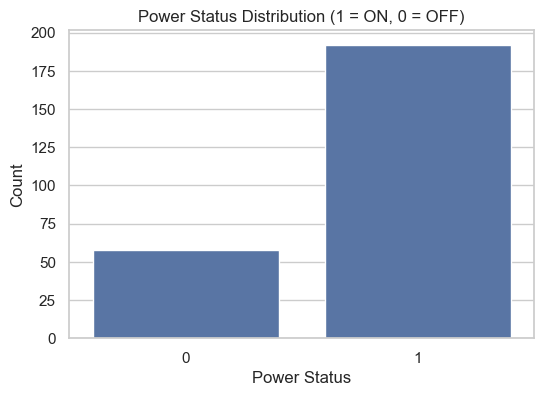

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# --- 1. Overall outage distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Outage', data=df)
plt.title("Power Status Distribution (1 = ON, 0 = OFF)")
plt.xlabel("Power Status")
plt.ylabel("Count")
plt.show()

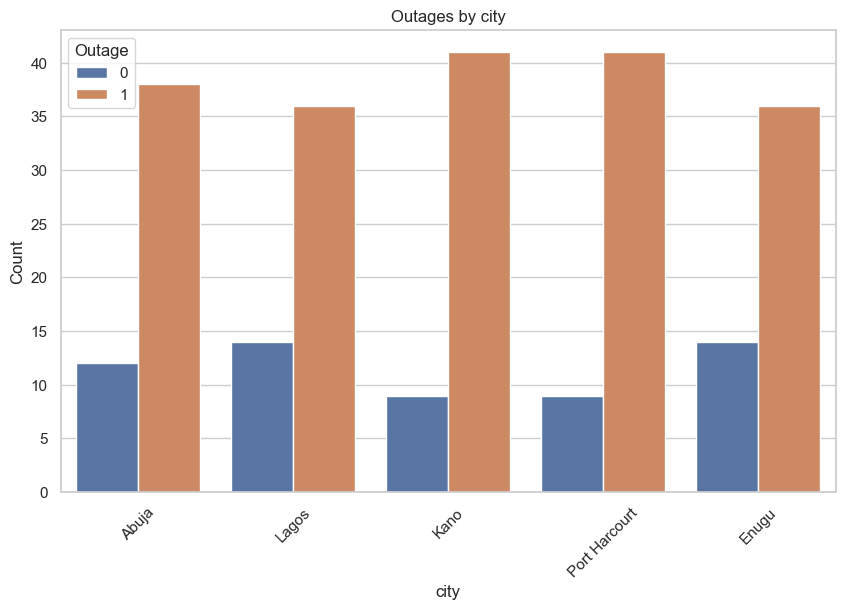

In [43]:
# --- 2. Outages by city ---
plt.figure(figsize=(10, 6))
sns.countplot(x='city', hue='Outage', data=df)
plt.title("Outages by city")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Outage')
plt.show()

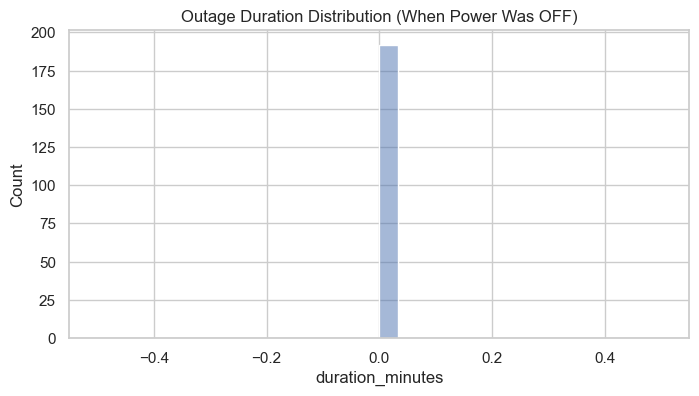

In [45]:
# --- 3. Outage Duration Distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['Outage'] == 1], x='duration_minutes', bins=30, kde=True)
plt.title("Outage Duration Distribution (When Power Was OFF)")
plt.xlabel("duration_minutes")
plt.show()

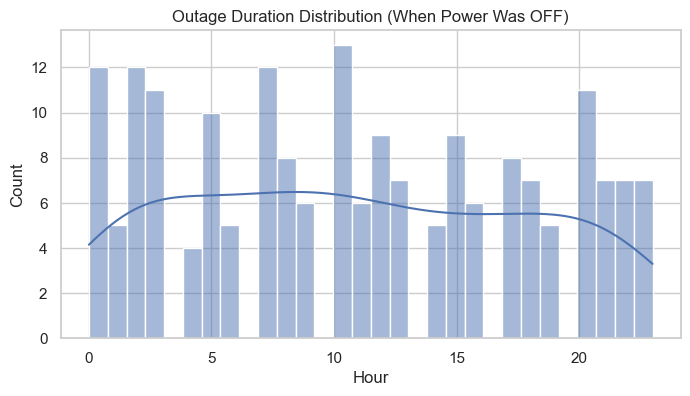

In [46]:
# --- 3. Outage Duration Distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['Outage'] == 1], x='Hour', bins=30, kde=True)
plt.title("Outage Duration Distribution (When Power Was OFF)")
plt.xlabel("Hour")
plt.show()

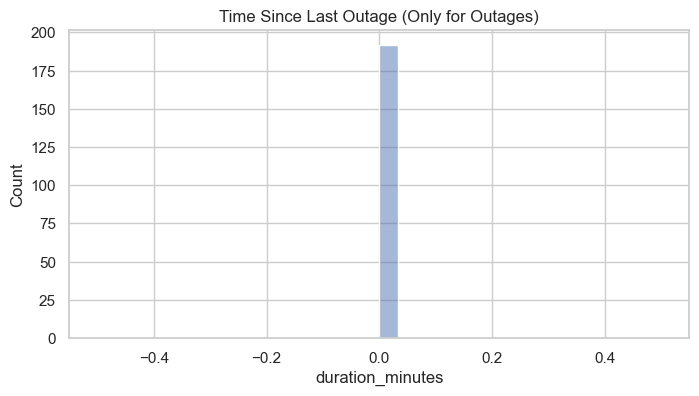

In [48]:
# --- 4. Time Since Last Outage ---
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['Outage'] == 1], x='duration_minutes', bins=30, kde=True)
plt.title("Time Since Last Outage (Only for Outages)")
plt.xlabel("duration_minutes")
plt.show()

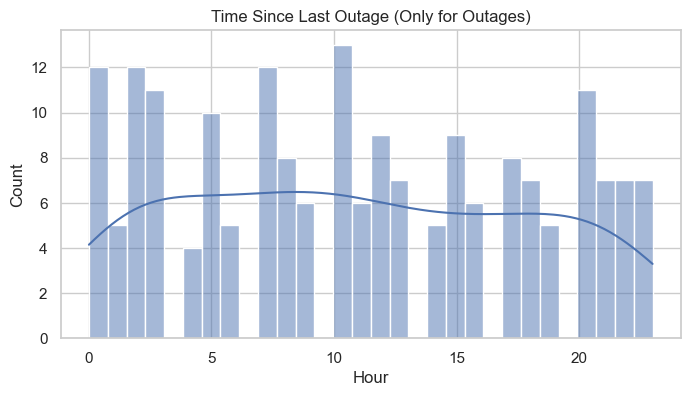

In [49]:
# --- 4. Time Since Last Outage ---
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['Outage'] == 1], x='Hour', bins=30, kde=True)
plt.title("Time Since Last Outage (Only for Outages)")
plt.xlabel("Hour")
plt.show()

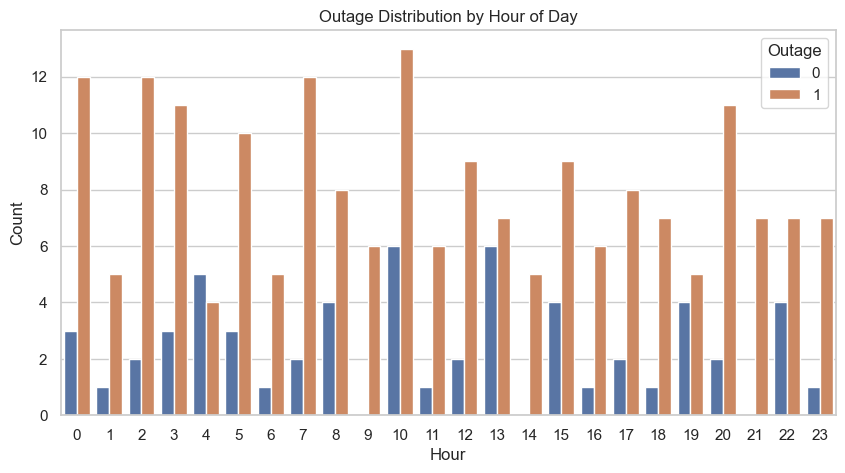

In [59]:
if 'Hour' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='Hour', hue='Outage', data=df)
    plt.title("Outage Distribution by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.legend(title='Outage')
    plt.show()

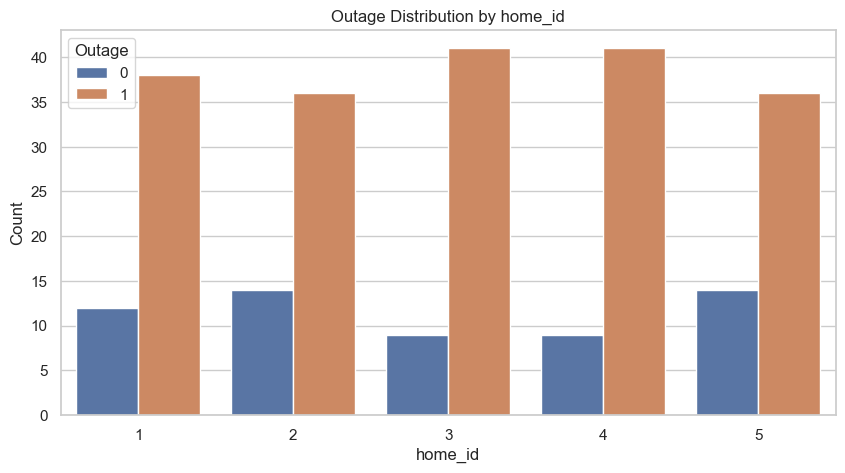

In [64]:
if 'home_id' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='home_id', hue='Outage', data=df)
    plt.title("Outage Distribution by home_id")
    plt.xlabel("home_id",)
    plt.ylabel("Count")
    plt.legend(title='Outage')
    plt.show()

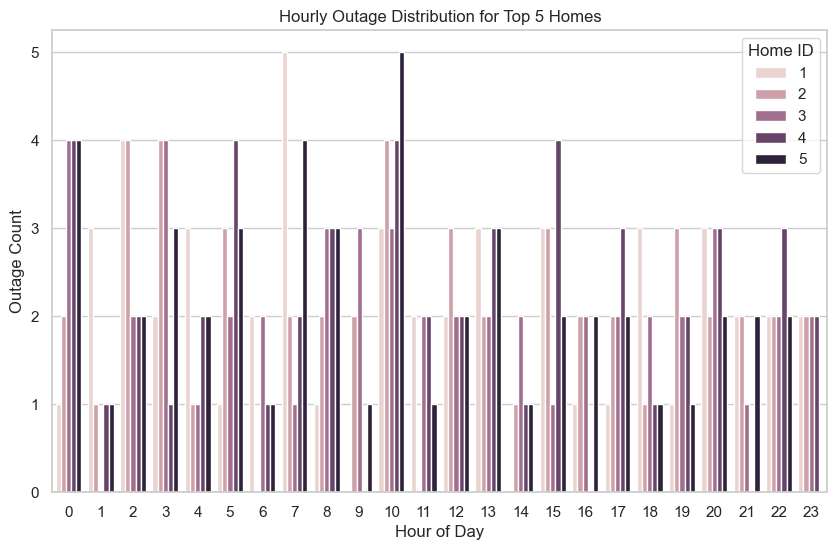

In [65]:

# Step 1: Select top 5 homes with most outages
top_homes = df[df['Outage'] == 1]['home_id'].value_counts().nlargest(5).index

# Step 2: Filter DataFrame for only those homes
df_top = df[df['home_id'].isin(top_homes)]

# Step 3: Plot outage by hour for each home
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top, x='Hour', hue='home_id')
plt.title("Hourly Outage Distribution for Top 5 Homes")
plt.xlabel("Hour of Day")
plt.ylabel("Outage Count")
plt.legend(title='Home ID')
plt.show()

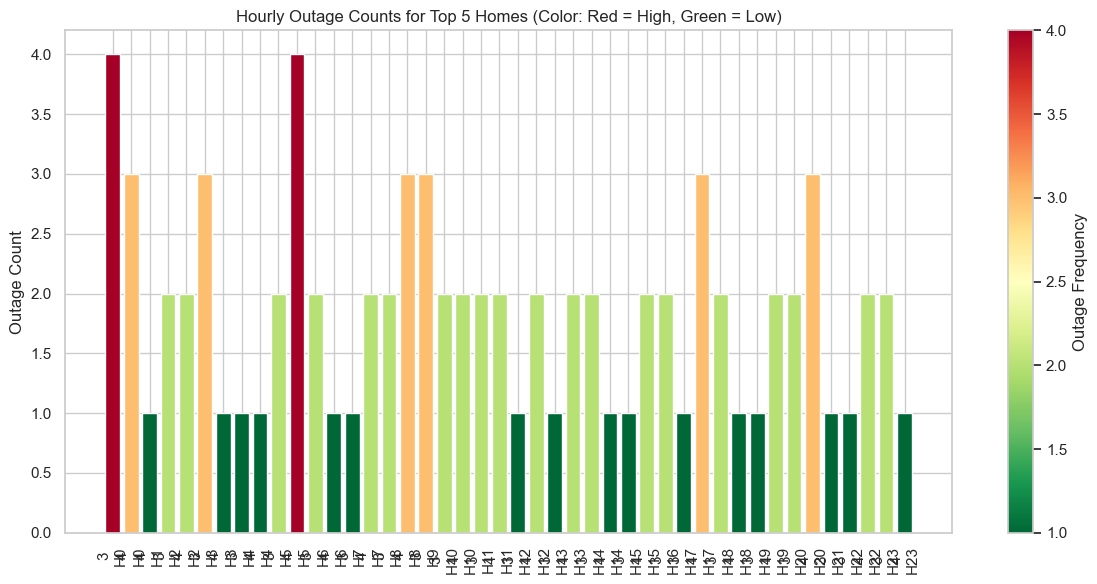

In [69]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Step 1: Top 3 homes with most outages
top_homes = df[df['Outage'] == 1]['home_id'].value_counts().nlargest(2).index
df_top = df[(df['home_id'].isin(top_homes)) & (df['Outage'] == 1)]

# Step 2: Group by Hour and Home ID
hourly_outages = df_top.groupby(['Hour', 'home_id']).size().reset_index(name='OutageCount')

# Step 3: Normalize color based on OutageCount
norm = Normalize(vmin=hourly_outages['OutageCount'].min(), vmax=hourly_outages['OutageCount'].max())
cmap = plt.cm.RdYlGn_r
colors = [cmap(norm(val)) for val in hourly_outages['OutageCount']]

# Step 4: Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    x=range(len(hourly_outages)),
    height=hourly_outages['OutageCount'],
    color=colors
)

# X-axis formatting
ax.set_title("Hourly Outage Counts for Top 5 Homes (Color: Red = High, Green = Low)")
ax.set_ylabel("Outage Count")
ax.set_xticks(ticks=range(len(hourly_outages)))
ax.set_xticklabels(
    [f"{row['home_id']}\nH{int(row['Hour'])}" for _, row in hourly_outages.iterrows()],
    rotation=90
)

# Step 5: Add colorbar explicitly to this axis
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(hourly_outages['OutageCount'])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Outage Frequency")

plt.tight_layout()
plt.show()

In [72]:
from sklearn.model_selection import train_test_split

# Step 1: Drop the target from features
X = df.drop(columns=['Outage'])

# Step 2: Set the target
y = df['Outage']

# Step 3: Handle non-numeric columns with one-hot encoding (e.g., Status, City)
X = pd.get_dummies(X, drop_first=True)

# Step 4: Fill any remaining NaNs
X = X.fillna(0)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Confirm result
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train value counts:\n", y_train.value_counts())
print("y_test value counts:\n", y_test.value_counts())

X_train shape: (200, 15)
X_test shape: (50, 15)
y_train value counts:
 Outage
1    154
0     46
Name: count, dtype: int64
y_test value counts:
 Outage
1    38
0    12
Name: count, dtype: int64


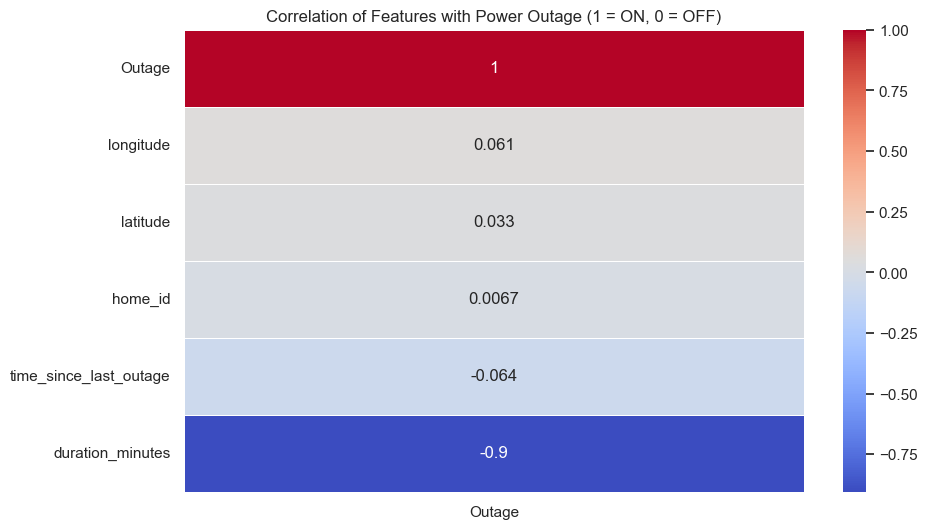

In [73]:


# Step 1: Select numeric features including 'Outage'
numeric_features = df.select_dtypes(include=['int64', 'float64']).copy()

# Step 2: Drop rows with NaN to avoid correlation errors
numeric_features = numeric_features.dropna()

# Step 3: Compute correlation matrix
correlation_matrix = numeric_features.corr()

# Step 4: Visualize as heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix[['Outage']].sort_values(by='Outage', ascending=False),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation of Features with Power Outage (1 = ON, 0 = OFF)")
plt.show()


In [75]:
# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Time-based features
df['Hour'] = df['timestamp'].dt.hour
df['DayOfWeek'] = df['timestamp'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['Month'] = df['timestamp'].dt.month
df['Day'] = df['timestamp'].dt.day


In [77]:
# Sort first
df.sort_values(by=['home_id', 'timestamp'], inplace=True)

# Previous outage indicator (shifted)
df['Prev_Outage'] = df.groupby('home_id')['Outage'].shift(1).fillna(0)

In [81]:
# Step 1: Drop the target from features
X = df.drop(columns=['Outage'])

# Step 2: Set the target
y = df['Outage']

# Step 3: Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Step 4: Fill missing values
X = X.fillna(0)

# Step 5: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Combine train set into a single DataFrame (optional but useful)
train_set = X_train.copy()
train_set['Outage'] = y_train

# Step 7: Combine test set too if needed
test_set = X_test.copy()
test_set['Outage'] = y_test

# Preview
print("Train set shape:", train_set.shape)
print("Test set shape:", test_set.shape)
print(train_set.head())

Train set shape: (200, 19)
Test set shape: (50, 19)
     home_id  latitude  longitude           timestamp  duration_minutes  \
229        5   6.52460    7.50860 2025-06-03 07:09:00                 0   
6          1   9.05785    7.49508 2025-06-01 12:45:00                 0   
49         1   9.05785    7.49508 2025-06-04 11:58:00                81   
235        5   6.52460    7.50860 2025-06-03 17:25:00                 0   
101        3  12.00220    8.59190 2025-06-01 00:50:00                 0   

     time_since_last_outage  Hour  DayOfWeek  Month  IsWeekend  Day  \
229                   119.0     7          1      6          0    3   
6                       0.0    12          6      6          1    1   
49                    421.0    11          2      6          0    4   
235                   398.0    17          1      6          0    3   
101                     0.0     0          6      6          1    1   

     Prev_Outage  city_Abuja  city_Enugu  city_Kano  city_Lagos  \
229

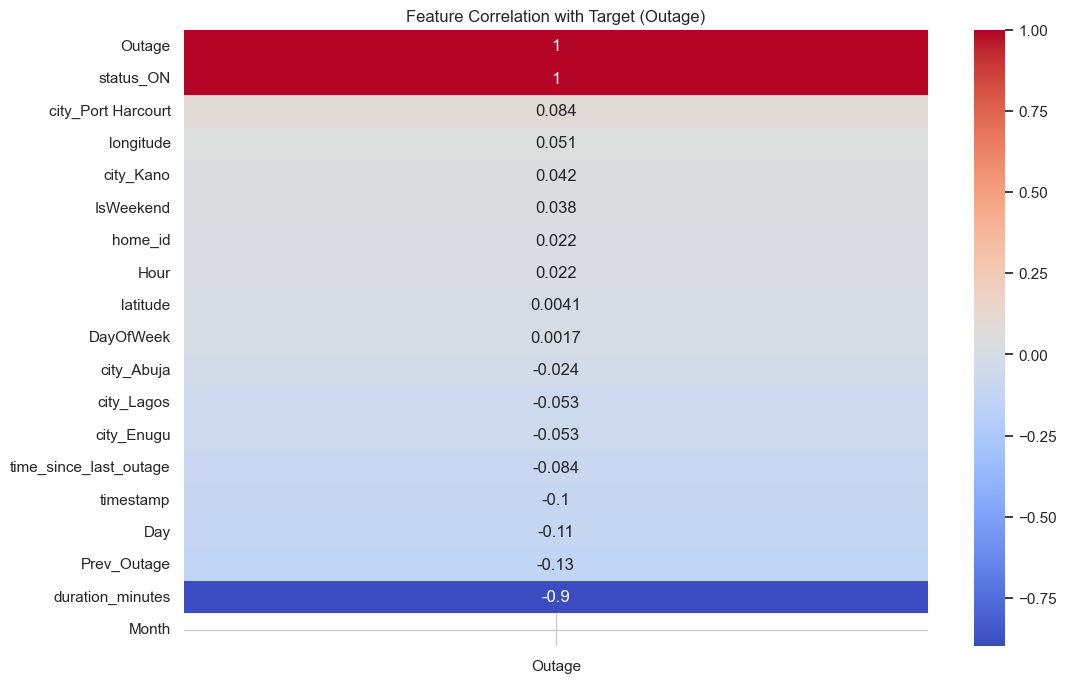

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Step 1: Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = train_set.corr()
sns.heatmap(corr_matrix[['Outage']].sort_values(by='Outage', ascending=False), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Target (Outage)")
plt.show()

# Step 2: Prepare training features/target
X_train = train_set.drop(columns=['Outage'])
y_train = train_set['Outage']
X_test = test_set.drop(columns=['Outage'])
y_test = test_set['Outage']



In [84]:
# Step 3: Train Models

# Drop datetime features if any exist
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remove them from both train and test
X_train = X_train.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)



In [85]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)



In [86]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



c:\Users\Adeola Yusuf\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:52:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [87]:
# Step 4: Evaluation Function
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_pred):.3f}")


In [88]:

# Step 5: Evaluate all models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


Logistic Regression Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

Random Forest Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

XGBoost Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000


In [89]:
print([col for col in X_train.columns if 'status' in col.lower() or 'duration' in col.lower()])


['duration_minutes', 'status_ON']


In [90]:
X_train = X_train.drop(columns=['duration_minutes', 'Status_OFF', 'Status_ON'], errors='ignore')
X_test = X_test.drop(columns=['duration_minutes', 'Status_OFF', 'Status_ON'], errors='ignore')

In [91]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Outage
1    0.77
0    0.23
Name: proportion, dtype: float64
Outage
1    0.76
0    0.24
Name: proportion, dtype: float64


In [94]:
# Step 3: Train Models

# Drop datetime features if any exist
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remove them from both train and test
X_train = X_train.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

In [95]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [96]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

c:\Users\Adeola Yusuf\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:58:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [97]:
# Step 4: Evaluation Function
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_pred):.3f}")

In [98]:
# Step 5: Evaluate all models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


Logistic Regression Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

Random Forest Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

XGBoost Results:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000


In [101]:

# Only use safe, basic features — drop anything that could be target-related
safe_columns = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month', 'latitude', 'longitude']
df_safe = df[safe_columns + ['Outage']].copy()

# Drop rows with missing target
df_safe = df_safe.dropna(subset=['Outage'])

# Features and target
X = df_safe.drop(columns=['Outage'])
y = df_safe['Outage']

# Fill missing values
X = X.fillna(0)

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train models again
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluation
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_pred):.3f}")

evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")




Logistic Regression Results:
Accuracy:  0.760
Precision: 0.760
Recall:    1.000
F1 Score:  0.864
ROC AUC:   0.500

Random Forest Results:
Accuracy:  0.740
Precision: 0.805
Recall:    0.868
F1 Score:  0.835
ROC AUC:   0.601

XGBoost Results:
Accuracy:  0.680
Precision: 0.789
Recall:    0.789
F1 Score:  0.789
ROC AUC:   0.561


c:\Users\Adeola Yusuf\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:02:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
